# Regularization

#### The Effect of Ridge on Multicollinearity
##### The Task: Create or find a dataset with highly correlated features (multicollinearity).
##### Objectives:
##### Train a standard Linear Regression model and a Ridge Regression model.
##### Compare the magnitude of the coefficients between the two models. Observe how Ridge penalizes and shrinks the coefficients of correlated features to stabilize the model.

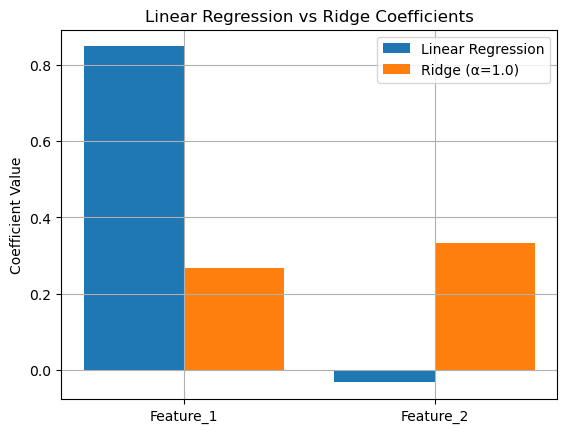

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
df = pd.read_csv("Multicollinear.csv")
X = df[["Feature_1", "Feature_2"]]
y = df["Feature_3"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)
model_R = Ridge(alpha=1.0)
model_R.fit(X_train, y_train)
labels = ["Feature_1", "Feature_2"]
x = range(len(labels))
plt.bar([i - 0.2 for i in x], model_LR.coef_, width=0.4, label="Linear Regression")
plt.bar([i + 0.2 for i in x], model_R.coef_,  width=0.4, label="Ridge (α=1.0)")
plt.xticks(x, labels)
plt.ylabel("Coefficient Value")
plt.title("Linear Regression vs Ridge Coefficients")
plt.legend()
plt.grid(True)
plt.show()

#### Feature Selection with Lasso CV
##### Dataset: from sklearn.datasets import make_regression
##### The Task: Use a dataset with many features, some of which are irrelevant (e.g., adding pure noise columns to a housing dataset).
##### Objectives:
##### Use LassoCV to automatically find the best regularization strength ( / alpha) via cross-validation.
##### Examine the final coefficients. Identify which features Lasso pushed exactly to zero, effectively performing automatic feature selection.

Best alpha: 0.3114

real_1: 0.2054
real_2: -0.1654
real_3: 9.3492
real_4: 78.4116
real_5: 0.1312
real_6: 34.5985
real_7: 8.0936
real_8: 36.0325
real_9: 0.1665
real_10: -0.1067
noise_1: -0.2705
noise_2: -0.8087
noise_3: 0.3208
noise_4: -0.0000
noise_5: -0.9502


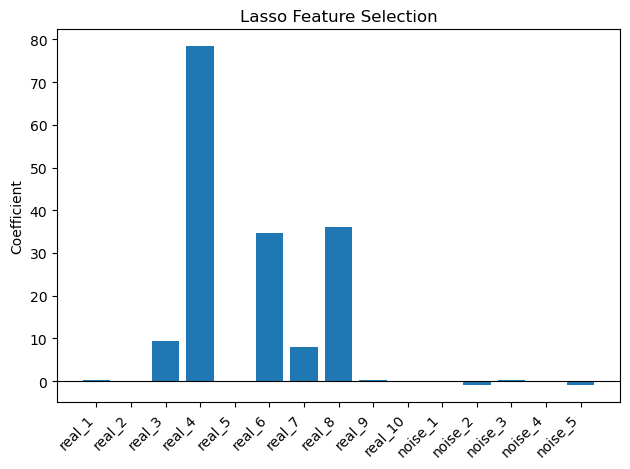

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X, y = make_regression(n_samples=200, n_features=10, n_informative=5, noise=10, random_state=42)
noise = np.random.randn(200, 5)
X = np.hstack([X, noise])
feature_names = [f"real_{i+1}" for i in range(10)] + [f"noise_{i+1}" for i in range(5)]
scaler = StandardScaler()
X = scaler.fit_transform(X)
lasso = LassoCV(cv=5)
lasso.fit(X, y)
plt.bar(feature_names, lasso.coef_)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Coefficient")
plt.title("Lasso Feature Selection")
plt.tight_layout()
plt.show()